In [36]:
# install day 11 requirements

%pip install torch torchvision numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [37]:
# imports

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, classification_report

In [38]:
# setup

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [39]:
# load CIFAR-10

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

train_dataset = datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=test_transform
)

print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))

Training samples: 50000
Testing samples : 10000


In [40]:
# class names

classes = train_dataset.classes

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [41]:
# create dataloaders

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Batches per epoch:", len(train_loader))

Batches per epoch: 391


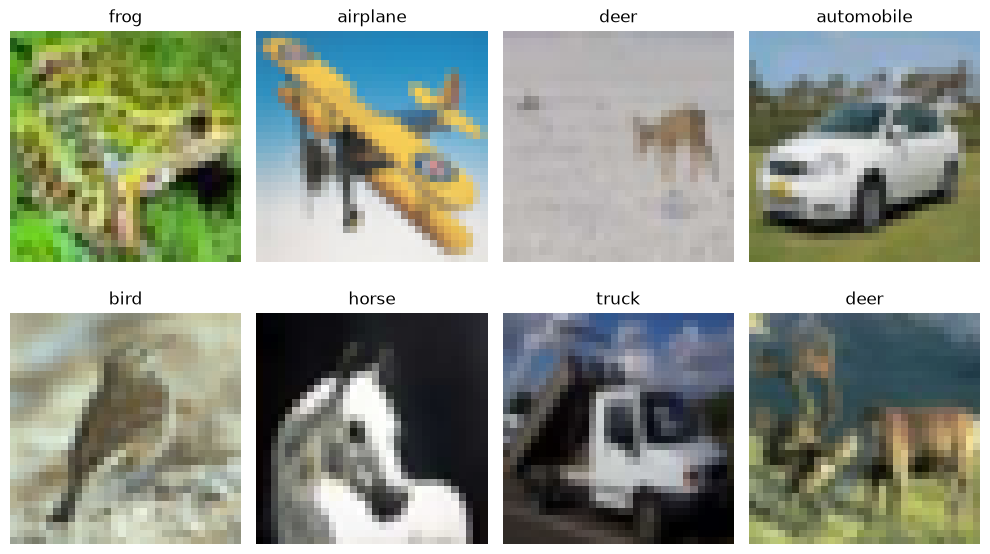

In [42]:
# quick look at the images

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    image = images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
# build our custom CNN

class CustomCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),

            # block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.30)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CustomCNN().to(device)

print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout2d(p=0.25, inplace=False)
    (13): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

In [44]:
# check the model

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters: 806,218
Trainable parameters: 806,218


In [45]:
# training setup

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

epochs = 15

print("Epochs:", epochs)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])

Epochs: 15
Initial learning rate: 0.001
Weight decay: 0.0001


In [46]:
# one training epoch

def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [47]:
# evaluate the model

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [48]:
# train the custom CNN

history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
    "learning_rate": []
}

best_accuracy = 0.0
best_state = None

start_time = time.perf_counter()

for epoch in range(epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion
    )

    scheduler.step(test_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)
    history["learning_rate"].append(current_lr)

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.4f} | "
        f"LR: {current_lr:.6f}"
    )

training_time = time.perf_counter() - start_time

print("\nTraining time:", round(training_time, 2), "seconds")
print("Best test accuracy:", round(best_accuracy, 4))

Epoch 01/15 | Train Loss: 1.4938 | Train Acc: 0.4559 | Test Loss: 1.0944 | Test Acc: 0.6059 | LR: 0.001000
Epoch 02/15 | Train Loss: 1.1228 | Train Acc: 0.5987 | Test Loss: 0.8990 | Test Acc: 0.6802 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.9686 | Train Acc: 0.6594 | Test Loss: 0.7782 | Test Acc: 0.7284 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.8680 | Train Acc: 0.6948 | Test Loss: 0.7207 | Test Acc: 0.7501 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.7956 | Train Acc: 0.7234 | Test Loss: 0.6961 | Test Acc: 0.7602 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.7422 | Train Acc: 0.7410 | Test Loss: 0.6633 | Test Acc: 0.7692 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.6934 | Train Acc: 0.7586 | Test Loss: 0.6181 | Test Acc: 0.7861 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.6603 | Train Acc: 0.7703 | Test Loss: 0.6255 | Test Acc: 0.7849 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.6197 | Train Acc: 0.7825 | Test Loss: 0.6045 | Test Acc: 0.7944 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.5898 | Tr

In [49]:
# keep the best checkpoint

model.load_state_dict(best_state)

print(
    "Restored model with test accuracy:",
    round(best_accuracy, 4)
)

Restored model with test accuracy: 0.8162


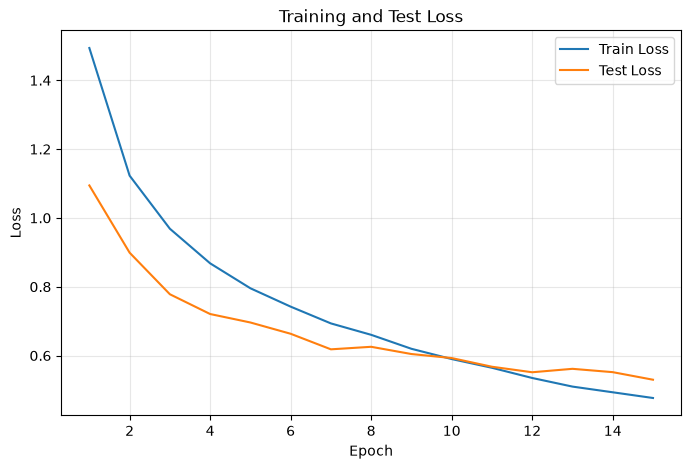

In [50]:
# check training progress

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

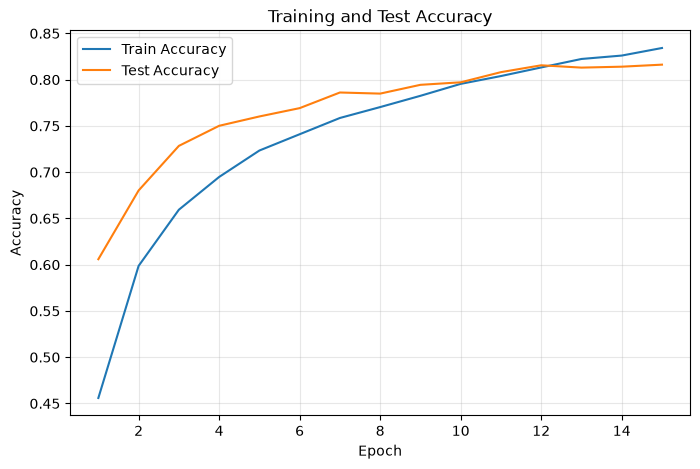

In [51]:
# accuracy progress

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["test_accuracy"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

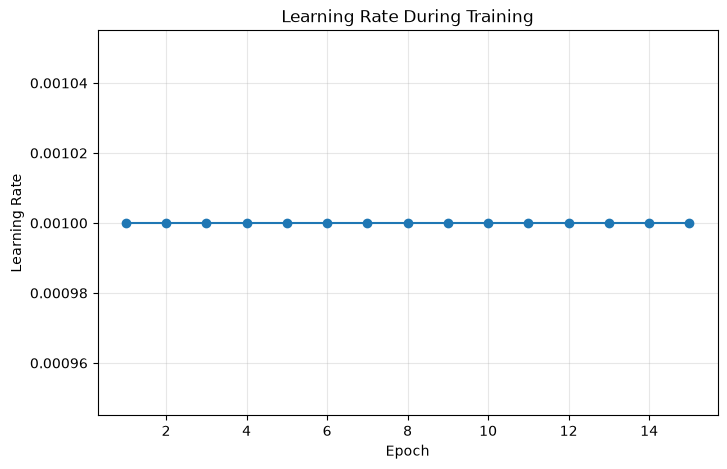

In [52]:
# learning-rate schedule

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["learning_rate"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate During Training")
plt.grid(alpha=0.3)

plt.show()

In [53]:
# final evaluation

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_predictions.extend(predictions)
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

final_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    "Final test accuracy:",
    round(final_accuracy, 4)
)

Final test accuracy: 0.8162


In [54]:
# detailed results

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.8477    0.8240    0.8357      1000
  automobile     0.9328    0.8880    0.9098      1000
        bird     0.7953    0.7070    0.7485      1000
         cat     0.6791    0.6030    0.6388      1000
        deer     0.7556    0.8410    0.7960      1000
         dog     0.7159    0.7460    0.7307      1000
        frog     0.8211    0.8950    0.8565      1000
       horse     0.8780    0.8490    0.8632      1000
        ship     0.8916    0.9050    0.8983      1000
       truck     0.8433    0.9040    0.8726      1000

    accuracy                         0.8162     10000
   macro avg     0.8160    0.8162    0.8150     10000
weighted avg     0.8160    0.8162    0.8150     10000



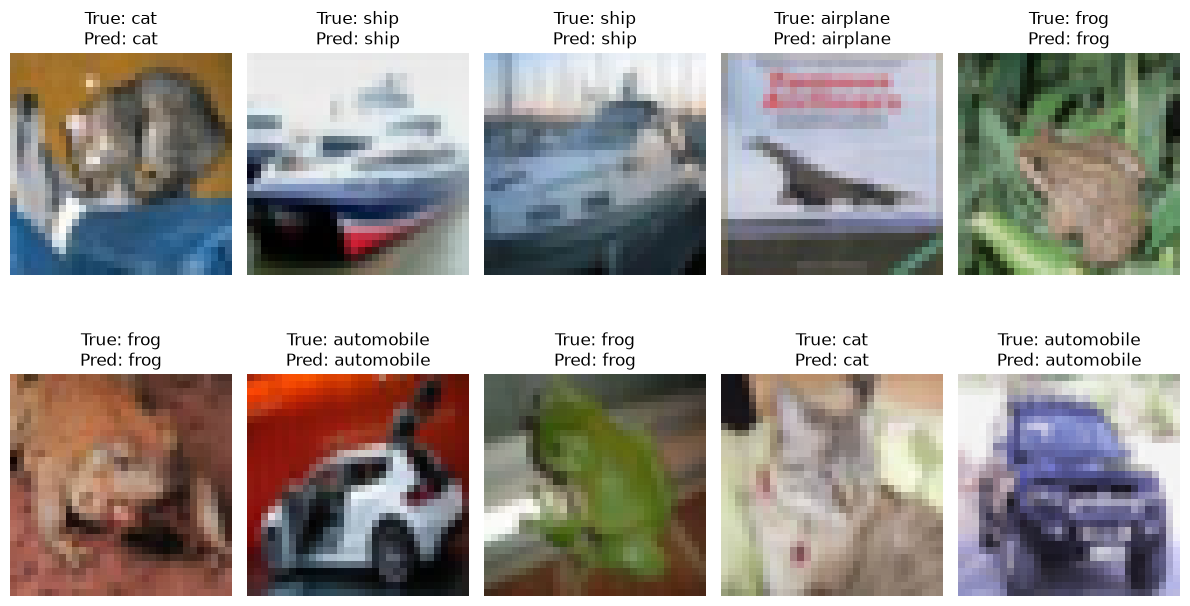

In [55]:
# look at some predictions

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    predictions = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(12, 7))

for i in range(10):

    image = images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)

    actual = classes[labels[i]]
    predicted = classes[predictions[i]]

    plt.title(
        f"True: {actual}\nPred: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
# save the model

import os

os.makedirs("../results", exist_ok=True)

model_path = "../results/day11_custom_cnn.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "classes": classes,
        "best_test_accuracy": best_accuracy,
        "architecture": "CustomCNN"
    },
    model_path
)

print("Model saved to:", model_path)

Model saved to: ../results/day11_custom_cnn.pth


In [61]:
# final result

print("=" * 55)
print("DAY 11 RESULTS")
print("=" * 55)

print(
    f"Model              : Custom CNN"
)

print(
    f"Test accuracy      : {final_accuracy:.4f}"
)

print(
    f"Best test accuracy : {best_accuracy:.4f}"
)

print(
    f"Training time      : {training_time:.2f} seconds"
)

print(
    f"Parameters         : {total_params:,}"
)

print(
    f"Weight decay       : {optimizer.param_groups[0]['weight_decay']}"
)

print(
    f"Dropout            : Applied"
)

print(
    f"Batch normalization : Applied"
)

print(
    f"LR scheduler       : Applied"
)

print("\nThe custom CNN was trained from scratch without a pretrained model.")

DAY 11 RESULTS
Model              : Custom CNN
Test accuracy      : 0.8162
Best test accuracy : 0.8162
Training time      : 1425.43 seconds
Parameters         : 806,218
Weight decay       : 0.0001
Dropout            : Applied
Batch normalization : Applied
LR scheduler       : Applied

The custom CNN was trained from scratch without a pretrained model.
